In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import json

ROOT = Path("..").resolve()

pred_path = ROOT / "data_processed" / "predictions_hgb_hierarchical_2022.csv"

df = pd.read_csv(pred_path)
df["invoice_date"] = pd.to_datetime(df["invoice_date"])

print("hierarchical predictions shape:", df.shape)
print("columns:", df.columns.tolist())
df.head()

hierarchical predictions shape: (152866, 15)
columns: ['store_id', 'invoice_date', 'invoice_count', 'oc_count', 'fleet_oc_count', 'non_fleet_oc', 'severity', 'pred_invoice', 'pred_non_fleet_oc', 'pred_fleet_oc', 'pred_oc_total', 'abs_err_invoice', 'abs_err_oc', 'oc_lower_95', 'oc_upper_95']


,store_id,invoice_date,invoice_count,oc_count,fleet_oc_count,non_fleet_oc,severity,pred_invoice,pred_non_fleet_oc,pred_fleet_oc,pred_oc_total,abs_err_invoice,abs_err_oc,oc_lower_95,oc_upper_95
0,79609,2022-01-02,37,31,3,28,sev_freezing,34.904848,26.133422,0.832786,26.966207,2.095152,4.033793,11.326312,42.529751
1,79609,2022-01-03,60,55,7,48,sev_freezing,58.718083,43.449059,5.084164,48.533223,1.281917,6.466777,32.893328,64.096767
2,79609,2022-01-04,62,50,5,45,sev_freezing,52.945849,40.869569,5.170848,46.040417,9.054151,3.959583,30.400522,61.603961
3,79609,2022-01-05,52,44,4,40,sev_freezing,53.302560,37.263945,4.685428,41.949373,1.302560,2.050627,26.309478,57.512918
4,79609,2022-01-06,16,13,1,12,sev_freezing,40.850080,29.404225,4.278599,33.682824,24.850080,20.682824,18.042930,49.246369


In [2]:
invoice_df = df[["store_id", "invoice_date", "invoice_count", "pred_invoice"]].copy()
invoice_df = invoice_df.rename(columns={
    "invoice_count": "actual",
    "pred_invoice": "pred"
})

oc_df = df[["store_id", "invoice_date", "oc_count", "pred_oc_total"]].copy()
oc_df = oc_df.rename(columns={
    "oc_count": "actual",
    "pred_oc_total": "pred"
})

print("invoice_df:", invoice_df.shape)
print("oc_df:", oc_df.shape)

invoice_df.head()

invoice_df: (152866, 4)
oc_df: (152866, 4)


,store_id,invoice_date,actual,pred
0,79609,2022-01-02,37,34.904848
1,79609,2022-01-03,60,58.718083
2,79609,2022-01-04,62,52.945849
3,79609,2022-01-05,52,53.302560
4,79609,2022-01-06,16,40.850080


In [3]:
def add_error_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["error"] = out["pred"] - out["actual"]              # signed error
    out["abs_error"] = (out["pred"] - out["actual"]).abs()  # absolute error
    out["month"] = out["invoice_date"].dt.month
    return out

invoice_df = add_error_columns(invoice_df)
oc_df = add_error_columns(oc_df)

invoice_df[["store_id", "invoice_date", "actual", "pred", "error", "abs_error"]].head()

,store_id,invoice_date,actual,pred,error,abs_error
0,79609,2022-01-02,37,34.904848,-2.095152,2.095152
1,79609,2022-01-03,60,58.718083,-1.281917,1.281917
2,79609,2022-01-04,62,52.945849,-9.054151,9.054151
3,79609,2022-01-05,52,53.302560,1.302560,1.302560
4,79609,2022-01-06,16,40.850080,24.850080,24.850080


In [4]:
def error_by_store(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby("store_id")
        .agg(
            n_days=("store_id", "size"),
            mean_actual=("actual", "mean"),
            mean_pred=("pred", "mean"),
            mae=("abs_error", "mean"),
            bias=("error", "mean"),
        )
        .sort_values("mae", ascending=False)
        .reset_index()
    )

invoice_store = error_by_store(invoice_df)
oc_store = error_by_store(oc_df)

print("Worst invoice_count stores by MAE:")
display(invoice_store.head(10))

print("Worst oc_count stores by MAE:")
display(oc_store.head(10))

Worst invoice_count stores by MAE:


,store_id,n_days,mean_actual,mean_pred,mae,bias
0,611652,358,128.125698,121.014908,22.334316,-7.110790
1,614420,358,74.427374,74.034057,11.631920,-0.393317
2,99215,354,61.963277,62.447549,11.044110,0.484272
3,614414,358,94.983240,93.620178,11.015307,-1.363062
4,614366,358,59.773743,56.477162,10.940160,-3.296581
5,615286,358,82.932961,82.657104,10.613307,-0.275857
6,231320,358,96.229050,94.638723,10.577341,-1.590328
7,615287,358,108.064246,106.985580,10.274924,-1.078666
8,615212,358,102.217877,100.439821,10.227103,-1.778056
9,84321,357,88.044818,87.004126,9.938351,-1.040692


Worst oc_count stores by MAE:


,store_id,n_days,mean_actual,mean_pred,mae,bias
0,99215,354,58.107345,58.853196,10.313214,0.745851
1,231320,358,91.008380,89.889698,10.076084,-1.118682
2,255712,358,65.019553,63.961160,9.049198,-1.058393
3,230586,358,80.846369,79.704708,8.957205,-1.141660
4,84321,357,78.316527,77.617514,8.806127,-0.699012
5,100510,358,80.896648,80.511367,8.798450,-0.385281
6,100502,352,54.482955,54.922346,8.511222,0.439391
7,86765,357,80.170868,79.613382,8.313630,-0.557487
8,232128,358,71.069832,71.798292,8.143036,0.728460
9,594271,358,68.586592,68.006615,8.115688,-0.579978


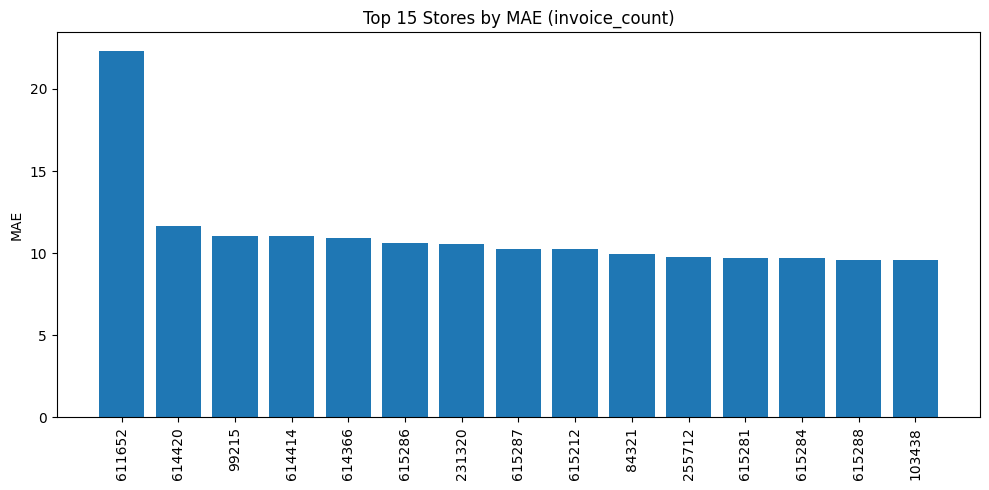

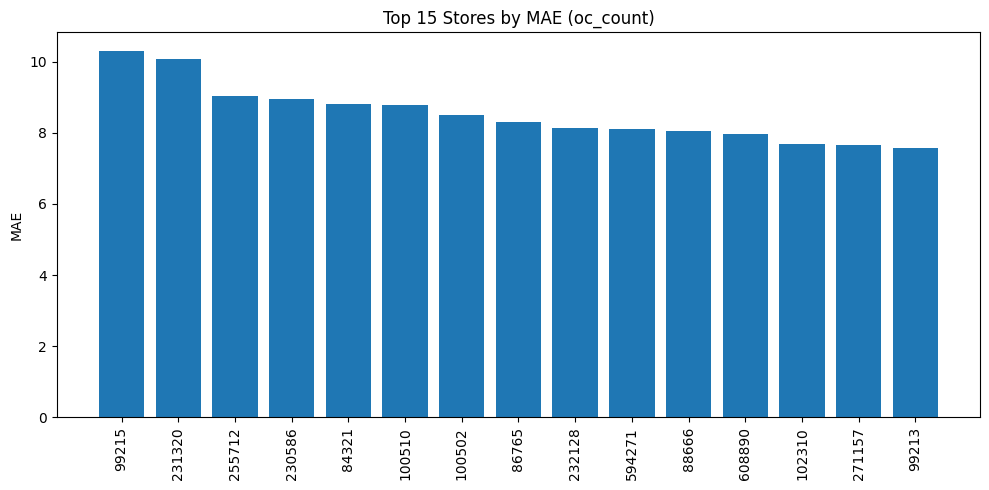

In [5]:
top_n = 15

plt.figure(figsize=(10, 5))
plt.bar(invoice_store["store_id"].astype(str).head(top_n), invoice_store["mae"].head(top_n))
plt.xticks(rotation=90)
plt.title("Top 15 Stores by MAE (invoice_count)")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(oc_store["store_id"].astype(str).head(top_n), oc_store["mae"].head(top_n))
plt.xticks(rotation=90)
plt.title("Top 15 Stores by MAE (oc_count)")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()

In [6]:
def error_by_month(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby("month")
        .agg(
            n_days=("month", "size"),
            mean_actual=("actual", "mean"),
            mae=("abs_error", "mean"),
            bias=("error", "mean"),
        )
        .reset_index()
        .sort_values("month")
    )

invoice_month = error_by_month(invoice_df)
oc_month = error_by_month(oc_df)

display(invoice_month)
display(oc_month)

,month,n_days,mean_actual,mae,bias
0,1,12698,50.261931,6.824229,-0.174082
1,2,11856,50.161859,7.267478,0.044222
2,3,13220,53.201815,6.145083,-0.652395
3,4,12379,52.142742,6.019874,-0.823278
4,5,12806,52.696939,6.220694,0.130819
5,6,12860,54.938414,6.148857,0.199698
6,7,12789,55.141684,6.403442,-0.288290
7,8,13280,53.517018,6.082251,-0.314648
8,9,12446,54.716134,6.234197,-0.692542
9,10,13250,52.833962,5.915972,0.108785


,month,n_days,mean_actual,mae,bias
0,1,12698,43.106552,6.093505,-0.048886
1,2,11856,43.345816,6.527188,-0.076481
2,3,13220,46.276248,5.514950,-0.511360
3,4,12379,45.375636,5.357708,-0.747031
4,5,12806,45.887553,5.547973,0.220204
5,6,12860,47.981726,5.444365,0.171630
6,7,12789,48.105012,5.619614,-0.199183
7,8,13280,46.628916,5.301694,-0.269091
8,9,12446,47.968745,5.584115,-0.674162
9,10,13250,46.287472,5.179590,-0.012916


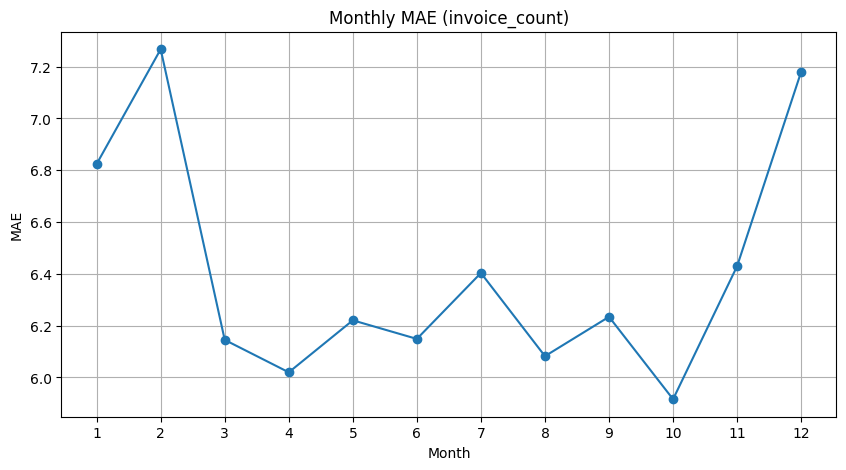

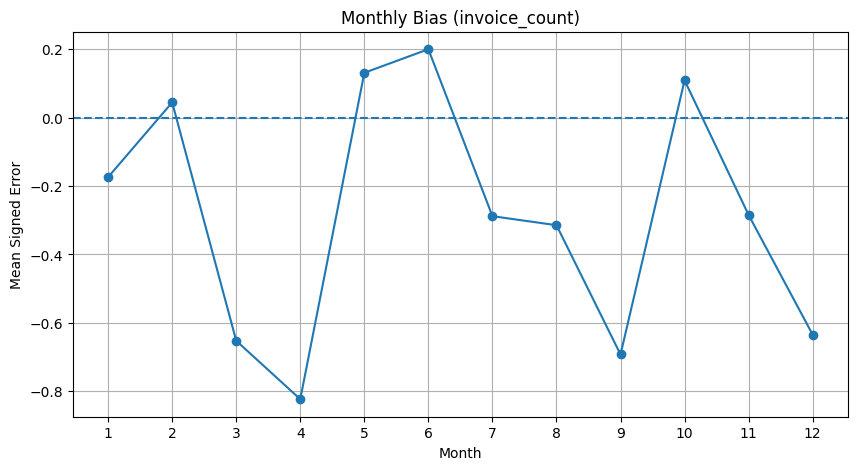

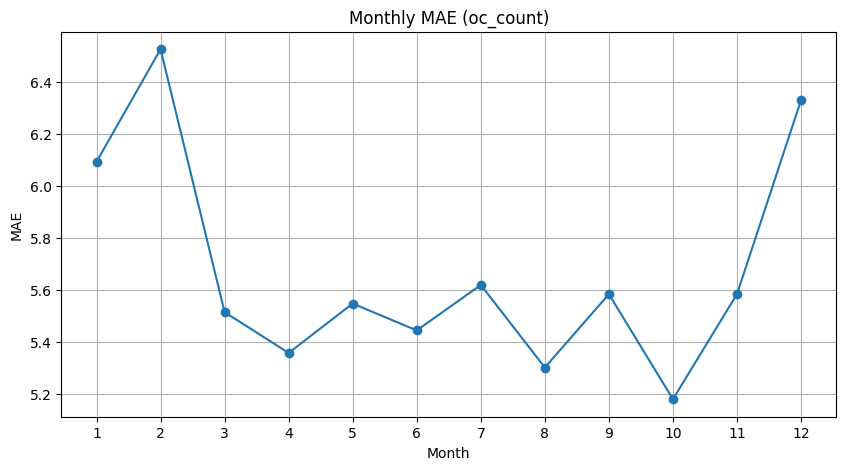

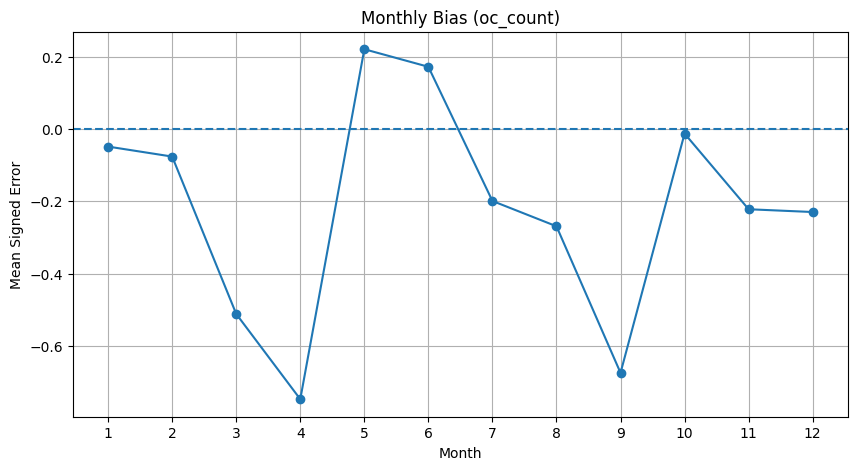

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(invoice_month["month"], invoice_month["mae"], marker="o")
plt.title("Monthly MAE (invoice_count)")
plt.xlabel("Month")
plt.ylabel("MAE")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(invoice_month["month"], invoice_month["bias"], marker="o")
plt.axhline(0, linestyle="--")
plt.title("Monthly Bias (invoice_count)")
plt.xlabel("Month")
plt.ylabel("Mean Signed Error")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(oc_month["month"], oc_month["mae"], marker="o")
plt.title("Monthly MAE (oc_count)")
plt.xlabel("Month")
plt.ylabel("MAE")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(oc_month["month"], oc_month["bias"], marker="o")
plt.axhline(0, linestyle="--")
plt.title("Monthly Bias (oc_count)")
plt.xlabel("Month")
plt.ylabel("Mean Signed Error")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

In [8]:
def add_volume_bucket(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    store_avg = out.groupby("store_id")["actual"].mean().rename("store_avg_actual")
    out = out.merge(store_avg, on="store_id", how="left")
    out["volume_bucket"] = pd.qcut(
        out["store_avg_actual"],
        q=4,
        labels=["Low", "Medium", "High", "Very High"],
        duplicates="drop"
    )
    return out

invoice_df = add_volume_bucket(invoice_df)
oc_df = add_volume_bucket(oc_df)

In [9]:
def error_by_volume_bucket(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby("volume_bucket")
        .agg(
            n_rows=("volume_bucket", "size"),
            mean_actual=("actual", "mean"),
            mae=("abs_error", "mean"),
            bias=("error", "mean"),
        )
        .reset_index()
    )

invoice_volume = error_by_volume_bucket(invoice_df)
oc_volume = error_by_volume_bucket(oc_df)

display(invoice_volume)
display(oc_volume)

/var/folders/tg/304lj0vs4yn7768vztr026j80000gn/T/ipykernel_98749/4228229534.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("volume_bucket")
/var/folders/tg/304lj0vs4yn7768vztr026j80000gn/T/ipykernel_98749/4228229534.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("volume_bucket")


,volume_bucket,n_rows,mean_actual,mae,bias
0,Low,38331,36.608098,5.358414,-0.017419
1,Medium,38134,46.616877,5.959600,-0.124379
2,High,38258,55.317189,6.590070,-0.339897
3,Very High,38143,72.680046,7.691946,-0.644681


,volume_bucket,n_rows,mean_actual,mae,bias
0,Low,38219,30.966980,4.733801,0.025354
1,Medium,38512,40.389022,5.400116,-0.089539
2,High,38059,48.597520,5.835750,-0.276456
3,Very High,38076,63.676568,6.703992,-0.522680


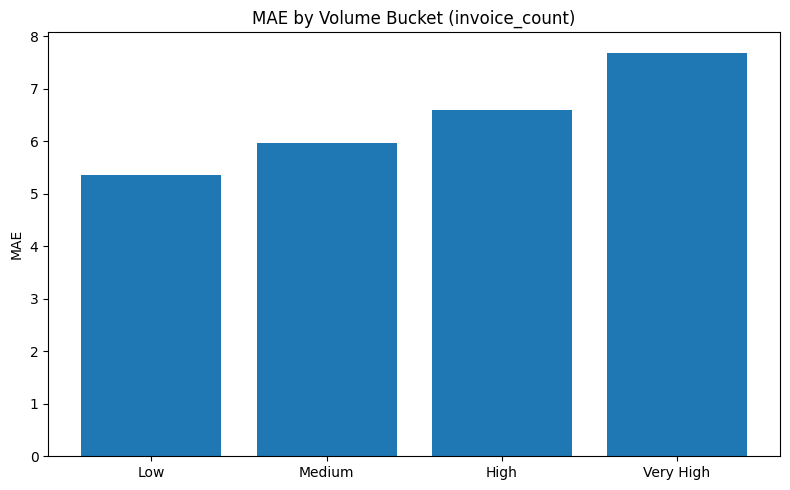

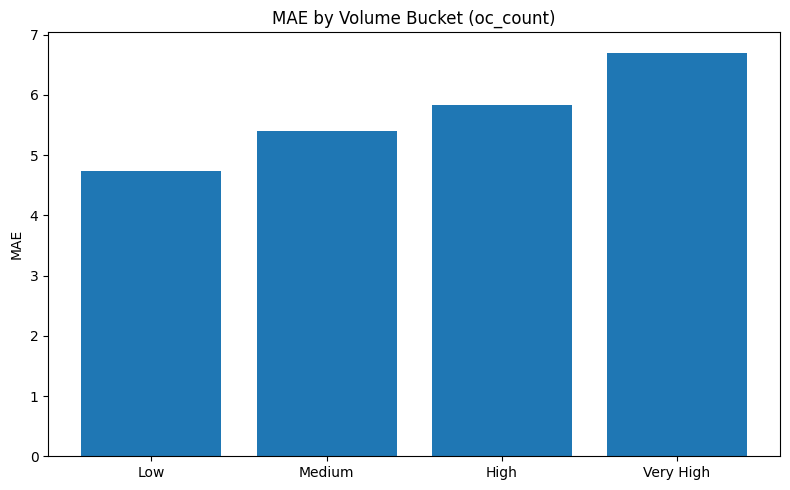

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(invoice_volume["volume_bucket"].astype(str), invoice_volume["mae"])
plt.title("MAE by Volume Bucket (invoice_count)")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(oc_volume["volume_bucket"].astype(str), oc_volume["mae"])
plt.title("MAE by Volume Bucket (oc_count)")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()

In [11]:
def bias_summary(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["direction"] = np.where(out["error"] > 0, "Overpredict", "Underpredict")
    return (
        out.groupby("direction")
        .agg(
            n=("direction", "size"),
            mean_abs_error=("abs_error", "mean"),
            mean_signed_error=("error", "mean"),
        )
        .reset_index()
    )

invoice_bias = bias_summary(invoice_df)
oc_bias = bias_summary(oc_df)

display(invoice_bias)
display(oc_bias)

,direction,n,mean_abs_error,mean_signed_error
0,Overpredict,74204,6.301338,6.301338
1,Underpredict,78662,6.490924,-6.490924


,direction,n,mean_abs_error,mean_signed_error
0,Overpredict,73891,5.639062,5.639062
1,Underpredict,78975,5.692668,-5.692668


In [12]:
print("Invoice overall bias:", invoice_df["error"].mean())
print("OC overall bias:", oc_df["error"].mean())

Invoice overall bias: -0.28132207725569586
OC overall bias: -0.21523770514605986


In [13]:
print("Worst invoice_count examples:")
display(invoice_df.sort_values("abs_error", ascending=False).head(10))

print("Worst oc_count examples:")
display(oc_df.sort_values("abs_error", ascending=False).head(10))

Worst invoice_count examples:


,store_id,invoice_date,actual,pred,error,abs_error,month,store_avg_actual,volume_bucket
34495,102098,2022-05-20,233,50.438473,-182.561527,182.561527,5,50.536932,Medium
77977,274137,2022-08-11,205,57.617651,-147.382349,147.382349,8,52.354749,High
59053,232116,2022-05-10,169,41.681254,-127.318746,127.318746,5,61.017192,Very High
6878,86960,2022-08-01,179,61.323807,-117.676193,117.676193,8,58.933718,High
8347,88321,2022-09-14,178,63.955060,-114.044940,114.044940,9,60.501401,High
35110,102302,2022-03-18,201,90.222159,-110.777841,110.777841,3,77.798883,Very High
4396,84970,2022-07-29,179,70.078011,-108.921989,108.921989,7,57.624294,High
54181,230659,2022-07-26,145,41.692602,-103.307398,103.307398,7,43.810056,Medium
11349,88666,2022-02-12,167,64.273030,-102.726970,102.726970,2,81.638655,Very High
65331,255712,2022-11-30,170,67.385215,-102.614785,102.614785,11,74.371508,Very High


Worst oc_count examples:


,store_id,invoice_date,actual,pred,error,abs_error,month,store_avg_actual,volume_bucket
34495,102098,2022-05-20,220,44.479734,-175.520266,175.520266,5,46.366477,High
59053,232116,2022-05-10,166,39.394574,-126.605426,126.605426,5,56.916905,Very High
35110,102302,2022-03-18,200,85.559977,-114.440023,114.440023,3,74.343575,Very High
6878,86960,2022-08-01,170,57.554761,-112.445239,112.445239,8,55.106628,Very High
4396,84970,2022-07-29,175,66.057859,-108.942141,108.942141,7,53.570621,High
59063,232116,2022-05-20,174,70.902068,-103.097932,103.097932,5,56.916905,Very High
11349,88666,2022-02-12,160,58.323915,-101.676085,101.676085,2,75.599440,Very High
102702,611637,2022-04-20,136,34.659177,-101.340823,101.340823,4,58.374302,Very High
54181,230659,2022-07-26,132,31.410030,-100.589970,100.589970,7,36.734637,Medium
52334,230652,2022-02-14,153,57.743714,-95.256286,95.256286,2,61.211268,Very High


In [14]:
summary = pd.DataFrame({
    "target": ["invoice_count", "oc_count"],
    "overall_mae": [
        invoice_df["abs_error"].mean(),
        oc_df["abs_error"].mean()
    ],
    "overall_bias": [
        invoice_df["error"].mean(),
        oc_df["error"].mean()
    ],
    "worst_month": [
        invoice_month.loc[invoice_month["mae"].idxmax(), "month"],
        oc_month.loc[oc_month["mae"].idxmax(), "month"]
    ],
    "worst_month_mae": [
        invoice_month["mae"].max(),
        oc_month["mae"].max()
    ],
    "worst_store": [
        invoice_store.loc[invoice_store["mae"].idxmax(), "store_id"],
        oc_store.loc[oc_store["mae"].idxmax(), "store_id"]
    ],
    "worst_store_mae": [
        invoice_store["mae"].max(),
        oc_store["mae"].max()
    ],
    "low_volume_mae": [
        invoice_volume.loc[invoice_volume["volume_bucket"] == "Low", "mae"].iloc[0],
        oc_volume.loc[oc_volume["volume_bucket"] == "Low", "mae"].iloc[0]
    ],
    "very_high_volume_mae": [
        invoice_volume.loc[invoice_volume["volume_bucket"] == "Very High", "mae"].iloc[0],
        oc_volume.loc[oc_volume["volume_bucket"] == "Very High", "mae"].iloc[0]
    ],
    "underprediction_count": [
        (invoice_df["error"] < 0).sum(),
        (oc_df["error"] < 0).sum()
    ],
    "overprediction_count": [
        (invoice_df["error"] > 0).sum(),
        (oc_df["error"] > 0).sum()
    ],
})

summary

,target,overall_mae,overall_bias,worst_month,worst_month_mae,worst_store,worst_store_mae,low_volume_mae,very_high_volume_mae,underprediction_count,overprediction_count
0,invoice_count,6.398896,-0.281322,2,7.267478,611652,22.334316,5.358414,7.691946,78662,74204
1,oc_count,5.666756,-0.215238,2,6.527188,99215,10.313214,4.733801,6.703992,78975,73891


## Key Findings

Based on the diagnostic analysis of the hierarchical HGB model on the 2022 validation dataset:

**Overall Model Accuracy**
- Invoice traffic prediction MAE: **6.40 visits**
- Oil change (OC) prediction MAE: **5.67 visits**
- These errors correspond to roughly **12–13% of average daily demand**, which is reasonable for daily retail forecasting.

**Prediction Bias**
- Invoice overall bias: **-0.28 visits**
- OC overall bias: **-0.22 visits**
- The model shows a **very slight tendency to underpredict**, but the bias magnitude is small.

**Store-Level Variability**
- Worst invoice store: **Store 611652 (MAE = 22.33 visits)**
- Worst OC store: **Store 99215 (MAE = 10.31 visits)**
- Most stores exhibit significantly lower errors, indicating stable performance across locations.

**Seasonal Patterns**
- Highest error occurs in **February**
  - Invoice MAE ≈ **7.27**
  - OC MAE ≈ **6.53**
- Lowest error occurs around **October**
  - Invoice MAE ≈ **5.92**
  - OC MAE ≈ **5.18**

**Demand Volume Effects**
Model error increases with store traffic volume:

| Volume Bucket | Invoice MAE | OC MAE |
|---------------|-------------|--------|
| Low           | 5.36        | 4.73   |
| Medium        | 5.96        | 5.40   |
| High          | 6.59        | 5.84   |
| Very High     | 7.69        | 6.70   |

**Prediction Direction**
- Underpredictions: **78,662**
- Overpredictions: **74,204**

The distribution of prediction errors is relatively balanced.

**Extreme Error Cases**
The largest errors occur during **rare demand spikes**, where actual store traffic exceeds typical historical patterns. In these cases the model predicts normal demand levels, producing large absolute errors.

## Interpretation

The hierarchical HGB forecasting model demonstrates **stable and reliable performance** for predicting daily store traffic and oil change demand.

First, the overall prediction errors remain relatively small compared to typical store traffic levels. With average daily traffic around 50 invoice visits and 43 oil changes, the observed MAE values (6–7 visits) indicate that the model captures the majority of demand variation.

Second, the model exhibits **minimal systematic bias**, meaning it does not consistently overestimate or underestimate demand. The slight negative bias suggests a small conservative tendency to underpredict demand, but the magnitude of this bias is negligible.

Third, the diagnostics reveal that **prediction error scales with store demand level**. High-volume stores naturally produce larger absolute errors because daily demand fluctuates more in these locations. However, the increase in error remains proportional to traffic levels, suggesting the model generalizes well across stores with different demand profiles.

Seasonal analysis also indicates that model performance remains **relatively stable throughout the year**. While February shows slightly higher errors, likely due to winter weather variability, the difference between the best and worst months is modest.

Finally, the largest prediction errors occur during **rare demand spikes**, where actual store visits greatly exceed normal levels. Such events are difficult for historical models to predict because they often arise from promotions, unusual weather conditions, or localized events that are not fully captured by historical features.

Overall, these diagnostics indicate that the hierarchical HGB model provides **consistent, unbiased, and operationally useful forecasts** for daily store demand.

## Weather Severity Validation Using Hierarchical Sprint 2 Outputs

This section validates the weather signal using the saved hierarchical prediction outputs. Instead of retraining a model, it examines how average demand changes across weather severity categories in the current Sprint 2 forecasting pipeline.

In [15]:
weather_impact = (
    df.groupby("severity")
    .agg(
        n_days=("severity", "size"),
        avg_invoice_actual=("invoice_count", "mean"),
        avg_invoice_pred=("pred_invoice", "mean"),
        avg_oc_actual=("oc_count", "mean"),
        avg_oc_pred=("pred_oc_total", "mean"),
        avg_oc_lower=("oc_lower_95", "mean"),
        avg_oc_upper=("oc_upper_95", "mean"),
    )
    .reset_index()
    .sort_values("avg_invoice_actual")
)

weather_impact

,severity,n_days,avg_invoice_actual,avg_invoice_pred,avg_oc_actual,avg_oc_pred,avg_oc_lower,avg_oc_upper
0,sev_cold_extreme,4812,48.729011,49.354675,42.633624,43.507278,21.025074,59.262685
4,sev_rain_heavy,7018,49.499573,49.557501,43.415788,43.563496,25.482297,58.420510
5,sev_snow_heavy,8537,50.328218,50.589445,43.307836,43.674361,24.554451,58.964062
1,sev_freezing,28107,51.728466,51.099669,45.337603,44.797269,29.168384,60.360813
3,sev_normal,98329,53.411913,53.126419,46.641235,46.382554,32.928735,60.440003
2,sev_heat_extreme,6063,58.069767,57.590474,45.036616,44.929548,31.636610,58.481803


In [16]:
normal_invoice = weather_impact.loc[
    weather_impact["severity"] == "sev_normal",
    "avg_invoice_actual"
].values[0]

normal_oc = weather_impact.loc[
    weather_impact["severity"] == "sev_normal",
    "avg_oc_actual"
].values[0]

weather_impact["invoice_change_vs_normal"] = (
    weather_impact["avg_invoice_actual"] - normal_invoice
)

weather_impact["oc_change_vs_normal"] = (
    weather_impact["avg_oc_actual"] - normal_oc
)

weather_impact

,severity,n_days,avg_invoice_actual,avg_invoice_pred,avg_oc_actual,avg_oc_pred,avg_oc_lower,avg_oc_upper,invoice_change_vs_normal,oc_change_vs_normal
0,sev_cold_extreme,4812,48.729011,49.354675,42.633624,43.507278,21.025074,59.262685,-4.682902,-4.007611
4,sev_rain_heavy,7018,49.499573,49.557501,43.415788,43.563496,25.482297,58.420510,-3.912341,-3.225447
5,sev_snow_heavy,8537,50.328218,50.589445,43.307836,43.674361,24.554451,58.964062,-3.083695,-3.333399
1,sev_freezing,28107,51.728466,51.099669,45.337603,44.797269,29.168384,60.360813,-1.683447,-1.303632
3,sev_normal,98329,53.411913,53.126419,46.641235,46.382554,32.928735,60.440003,0.000000,0.000000
2,sev_heat_extreme,6063,58.069767,57.590474,45.036616,44.929548,31.636610,58.481803,4.657854,-1.604620


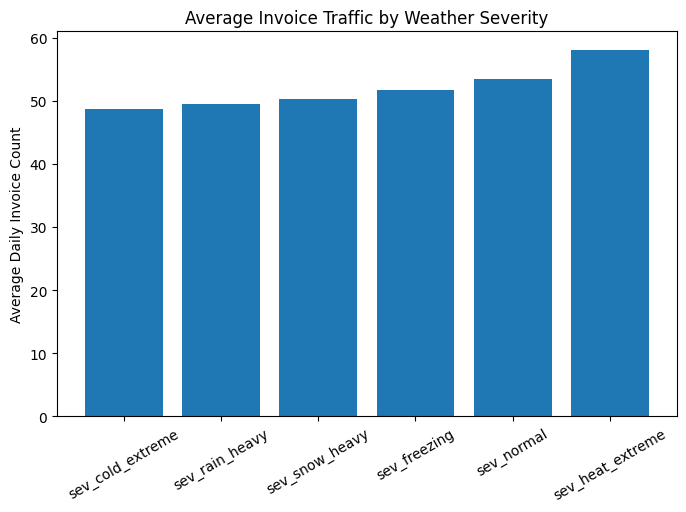

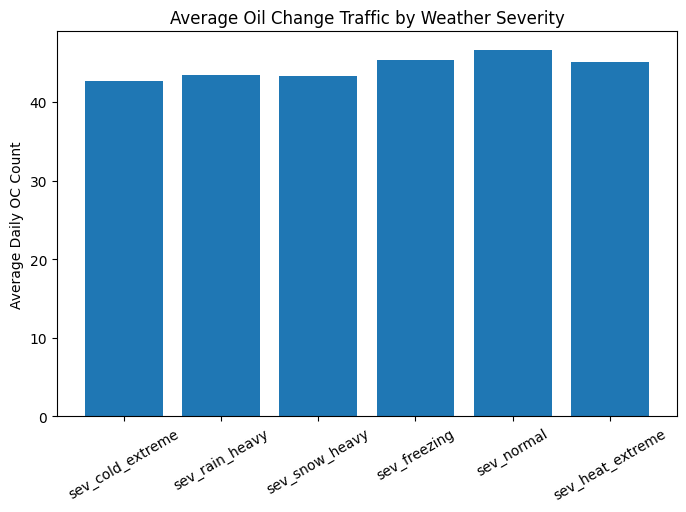

In [17]:
plt.figure(figsize=(8,5))
plt.bar(weather_impact["severity"], weather_impact["avg_invoice_actual"])
plt.title("Average Invoice Traffic by Weather Severity")
plt.ylabel("Average Daily Invoice Count")
plt.xticks(rotation=30)
plt.show()


plt.figure(figsize=(8,5))
plt.bar(weather_impact["severity"], weather_impact["avg_oc_actual"])
plt.title("Average Oil Change Traffic by Weather Severity")
plt.ylabel("Average Daily OC Count")
plt.xticks(rotation=30)
plt.show()

## Key Findings 

Average demand varies meaningfully across weather severity categories.

For `invoice_count`:

- `sev_normal` averages **53.41**
- `sev_freezing` averages **51.73**
- `sev_snow_heavy` averages **50.33**
- `sev_rain_heavy` averages **49.50**
- `sev_cold_extreme` averages **48.73**
- `sev_heat_extreme` averages **58.07**

Relative to normal conditions, invoice traffic is lower on:

- **extreme cold** by **4.68**
- **heavy rain** by **3.91**
- **heavy snow** by **3.08**
- **freezing days** by **1.68**

For `oc_count`:

- `sev_normal` averages **46.64**
- `sev_freezing` averages **45.34**
- `sev_heat_extreme` averages **45.04**
- `sev_rain_heavy` averages **43.42**
- `sev_snow_heavy` averages **43.31**
- `sev_cold_extreme` averages **42.63**

Relative to normal conditions, oil-change demand is lower on:

- **extreme cold** by **4.01**
- **heavy snow** by **3.33**
- **heavy rain** by **3.23**
- **extreme heat** by **1.60**
- **freezing days** by **1.30**

These results show that weather severity affects demand in a meaningful but **type-specific** way.

## Interpretation

The severity-based analysis validates the project’s business story using the current hierarchical forecasting outputs.

Cold-weather severity categories such as extreme cold, heavy snow, and freezing conditions are associated with lower average traffic than normal days. Heavy rain also reduces demand. This supports the interpretation that adverse travel conditions suppress store visits and oil-change activity.

At the same time, the effect of weather is **not uniformly negative across all severity types**. Extreme heat behaves differently from cold-weather severity and shows higher invoice traffic than normal days, while still showing lower oil-change traffic than normal. This suggests that different weather types affect customer behavior differently.

Together, Task 4A and Task 4B support a consistent interpretation:

- recurring traffic patterns define the baseline demand level
- weather shifts demand upward or downward around that baseline
- the direction and magnitude of the shift depend on the type of weather severity

This makes the model more useful for operational planning because it captures both stable demand structure and weather-driven variation.

## Feature Importance and Weather Contribution Analysis

This section uses the project DatasetBuilder-based feature pipeline to evaluate which inputs drive HGB forecast performance and whether weather-related variables provide measurable predictive value. A full model is compared against a no-weather version to quantify the contribution of weather signals directly.

In [23]:
import sys
from pathlib import Path

ROOT = Path("..").resolve()
SRC = ROOT / "src"

for p in [ROOT, SRC]:
    if str(p) not in sys.path:
        sys.path.append(str(p))

print("ROOT:", ROOT)
print("SRC:", SRC)

ROOT: /Users/harshini/GenAI-Weather-Based-Store-Analytics
SRC: /Users/harshini/GenAI-Weather-Based-Store-Analytics/src


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from dataset import DatasetBuilder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.inspection import permutation_importance

TARGET = "invoice_count"   # change to "oc_count" later

builder = DatasetBuilder(cutoff="2022-01-01")
train_df = builder.train.copy()
valid_df = builder.valid.copy()

print("train:", train_df.shape)
print("valid:", valid_df.shape)
print("columns:", len(train_df.columns))

train: (603838, 71)
valid: (152866, 71)
columns: 71


In [31]:
def build_feature_sets_current(df: pd.DataFrame):
    leakage_cols = ["invoice_count", "oc_count", "fleet_oc_count"]
    non_feature_cols = ["invoice_date"]

    feature_cols = [c for c in df.columns if c not in leakage_cols + non_feature_cols]

    categorical_candidates = [
        "store_id",
        "rain_bucket",
        "snow_bucket",
        "heat_bucket",
        "cold_bucket",
        "severity",
        "market_id",
        "store_state",
        "time_zone_code",
        "area_id",
        "marketing_area_id",
    ]

    categorical_cols = [c for c in categorical_candidates if c in feature_cols]
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    return feature_cols, categorical_cols, numeric_cols

In [32]:
feature_cols, categorical_cols, numeric_cols = build_feature_sets_current(train_df)

print("feature count:", len(feature_cols))
print("categorical:", categorical_cols)
print("numeric count:", len(numeric_cols))
print("first 20 features:", feature_cols[:20])

feature count: 67
categorical: ['store_id', 'rain_bucket', 'snow_bucket', 'heat_bucket', 'cold_bucket', 'severity', 'market_id', 'store_state', 'time_zone_code', 'area_id', 'marketing_area_id']
numeric count: 56
first 20 features: ['store_id', 'rain_bucket', 'snow_bucket', 'heat_bucket', 'cold_bucket', 'severity', 'market_id', 'store_state', 'time_zone_code', 'area_id', 'marketing_area_id', 'dow', 'month', 'day_of_year', 'is_weekend', 'tmin', 'tmax', 'tavg', 'rain_mm', 'snow_cm']


In [33]:
weather_keywords = [
    "tavg", "tmin", "tmax", "prcp", "snow", "wspd",
    "rain", "freezing", "heat", "cold", "weather"
]

def is_weather_feature(col: str) -> bool:
    c = col.lower()
    return any(k in c for k in weather_keywords)

weather_cols = [c for c in feature_cols if is_weather_feature(c)]
non_weather_cols = [c for c in feature_cols if c not in weather_cols]

print("weather_cols:", len(weather_cols))
print("non_weather_cols:", len(non_weather_cols))
print("weather examples:", weather_cols[:20])

weather_cols: 36
non_weather_cols: 31
weather examples: ['rain_bucket', 'snow_bucket', 'heat_bucket', 'cold_bucket', 'tmin', 'tmax', 'tavg', 'rain_mm', 'snow_cm', 'wspd', 'heavy_rain', 'heavy_snow', 'extreme_heat', 'extreme_cold', 'freezing', 'heavy_rain_weekend', 'heavy_snow_weekend', 'extreme_heat_weekend', 'snow_freezing', 'heavy_rain_capacity']


In [34]:
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def train_hgb_pipeline(train_df, valid_df, target, feature_cols, categorical_cols):
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    X_train = train_df[feature_cols].copy()
    y_train = train_df[target].astype(float).copy()

    X_valid = valid_df[feature_cols].copy()
    y_valid = valid_df[target].astype(float).copy()

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", make_ohe(), [c for c in categorical_cols if c in feature_cols]),
            ("num", SimpleImputer(strategy="median"), numeric_cols),
        ],
        remainder="drop",
    )

    model = HistGradientBoostingRegressor(
        random_state=42,
        learning_rate=0.05,
        max_iter=400,
        max_depth=None,
    )

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model),
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_valid)
    mae = mean_absolute_error(y_valid, pred)

    return pipe, mae, X_valid, y_valid

In [35]:
full_pipe, full_mae, X_valid_full, y_valid_full = train_hgb_pipeline(
    train_df=train_df,
    valid_df=valid_df,
    target=TARGET,
    feature_cols=feature_cols,
    categorical_cols=categorical_cols,
)

print("Full model MAE:", full_mae)

Full model MAE: 6.425706366256688


In [36]:
categorical_cols_no_weather = [c for c in categorical_cols if c in non_weather_cols]

no_weather_pipe, no_weather_mae, X_valid_no_weather, y_valid_no_weather = train_hgb_pipeline(
    train_df=train_df,
    valid_df=valid_df,
    target=TARGET,
    feature_cols=non_weather_cols,
    categorical_cols=categorical_cols_no_weather,
)

print("No-weather model MAE:", no_weather_mae)
print("MAE delta (no_weather - full):", no_weather_mae - full_mae)

No-weather model MAE: 6.5302744813431675
MAE delta (no_weather - full): 0.10456811508647945


In [37]:
perm = permutation_importance(
    full_pipe,
    X_valid_full,
    y_valid_full,
    n_repeats=5,
    random_state=42,
    scoring="neg_mean_absolute_error",
)

importance_df = pd.DataFrame({
    "feature": X_valid_full.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

importance_df.head(20)

,feature,importance_mean,importance_std
43,invoice_count_rollmean_7,3.485112,0.013274
11,dow,3.240489,0.008050
44,invoice_count_rollmean_28,1.188166,0.009106
40,invoice_count_lag_1,0.583882,0.006212
13,day_of_year,0.388354,0.003320
41,invoice_count_lag_7,0.196090,0.001092
18,rain_mm,0.151161,0.003330
42,invoice_count_lag_14,0.133700,0.004029
0,store_id,0.089132,0.002256
6,market_id,0.085513,0.001402


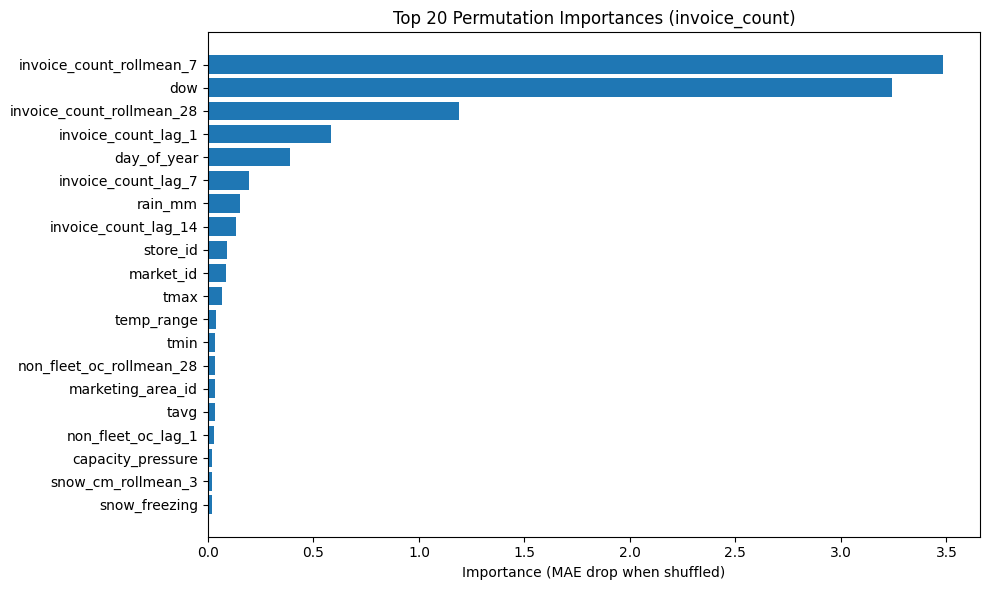

In [38]:
top20 = importance_df.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top20["feature"][::-1], top20["importance_mean"][::-1])
plt.title(f"Top 20 Permutation Importances ({TARGET})")
plt.xlabel("Importance (MAE drop when shuffled)")
plt.tight_layout()
plt.show()

In [39]:
importance_df["is_weather"] = importance_df["feature"].apply(is_weather_feature)

weather_summary = (
    importance_df.groupby("is_weather", as_index=False)["importance_mean"]
    .sum()
    .sort_values("importance_mean", ascending=False)
)

weather_summary

,is_weather,importance_mean
0,False,9.637273
1,True,0.467230


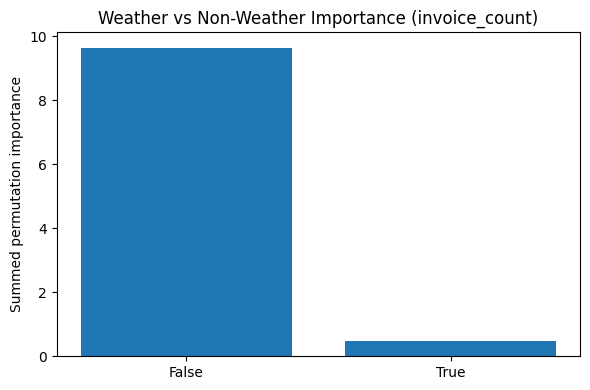

In [40]:
plt.figure(figsize=(6, 4))
plt.bar(weather_summary["is_weather"].astype(str), weather_summary["importance_mean"])
plt.title(f"Weather vs Non-Weather Importance ({TARGET})")
plt.ylabel("Summed permutation importance")
plt.tight_layout()
plt.show()

In [41]:
TARGET_OC = "oc_count"
print("Now analyzing:", TARGET_OC)

Now analyzing: oc_count


In [42]:
feature_cols_oc, categorical_cols_oc, numeric_cols_oc = build_feature_sets_current(train_df)

print("feature count (oc):", len(feature_cols_oc))
print("categorical (oc):", categorical_cols_oc)
print("numeric count (oc):", len(numeric_cols_oc))
print("first 20 features (oc):", feature_cols_oc[:20])

feature count (oc): 67
categorical (oc): ['store_id', 'rain_bucket', 'snow_bucket', 'heat_bucket', 'cold_bucket', 'severity', 'market_id', 'store_state', 'time_zone_code', 'area_id', 'marketing_area_id']
numeric count (oc): 56
first 20 features (oc): ['store_id', 'rain_bucket', 'snow_bucket', 'heat_bucket', 'cold_bucket', 'severity', 'market_id', 'store_state', 'time_zone_code', 'area_id', 'marketing_area_id', 'dow', 'month', 'day_of_year', 'is_weekend', 'tmin', 'tmax', 'tavg', 'rain_mm', 'snow_cm']


In [43]:
weather_cols_oc = [c for c in feature_cols_oc if is_weather_feature(c)]
non_weather_cols_oc = [c for c in feature_cols_oc if c not in weather_cols_oc]

print("weather_cols (oc):", len(weather_cols_oc))
print("non_weather_cols (oc):", len(non_weather_cols_oc))
print("weather examples (oc):", weather_cols_oc[:20])

weather_cols (oc): 36
non_weather_cols (oc): 31
weather examples (oc): ['rain_bucket', 'snow_bucket', 'heat_bucket', 'cold_bucket', 'tmin', 'tmax', 'tavg', 'rain_mm', 'snow_cm', 'wspd', 'heavy_rain', 'heavy_snow', 'extreme_heat', 'extreme_cold', 'freezing', 'heavy_rain_weekend', 'heavy_snow_weekend', 'extreme_heat_weekend', 'snow_freezing', 'heavy_rain_capacity']


In [44]:
full_pipe_oc, full_mae_oc, X_valid_full_oc, y_valid_full_oc = train_hgb_pipeline(
    train_df=train_df,
    valid_df=valid_df,
    target=TARGET_OC,
    feature_cols=feature_cols_oc,
    categorical_cols=categorical_cols_oc,
)

print("Full model MAE (oc):", full_mae_oc)

Full model MAE (oc): 5.700330507411195


In [45]:
categorical_cols_no_weather_oc = [c for c in categorical_cols_oc if c in non_weather_cols_oc]

no_weather_pipe_oc, no_weather_mae_oc, X_valid_no_weather_oc, y_valid_no_weather_oc = train_hgb_pipeline(
    train_df=train_df,
    valid_df=valid_df,
    target=TARGET_OC,
    feature_cols=non_weather_cols_oc,
    categorical_cols=categorical_cols_no_weather_oc,
)

print("No-weather model MAE (oc):", no_weather_mae_oc)
print("MAE delta (no_weather - full) (oc):", no_weather_mae_oc - full_mae_oc)

No-weather model MAE (oc): 5.8244474640988635
MAE delta (no_weather - full) (oc): 0.12411695668766853


In [46]:
perm_oc = permutation_importance(
    full_pipe_oc,
    X_valid_full_oc,
    y_valid_full_oc,
    n_repeats=5,
    random_state=42,
    scoring="neg_mean_absolute_error",
)

importance_df_oc = pd.DataFrame({
    "feature": X_valid_full_oc.columns,
    "importance_mean": perm_oc.importances_mean,
    "importance_std": perm_oc.importances_std,
}).sort_values("importance_mean", ascending=False)

importance_df_oc.head(20)

,feature,importance_mean,importance_std
48,non_fleet_oc_rollmean_7,2.943581,0.014956
11,dow,2.736122,0.009476
49,non_fleet_oc_rollmean_28,0.978376,0.007600
45,non_fleet_oc_lag_1,0.375818,0.006499
13,day_of_year,0.373374,0.002509
46,non_fleet_oc_lag_7,0.170240,0.001453
18,rain_mm,0.150132,0.002804
47,non_fleet_oc_lag_14,0.136582,0.003661
43,invoice_count_rollmean_7,0.102750,0.004055
54,fleet_oc_count_rollmean_28,0.096525,0.002724


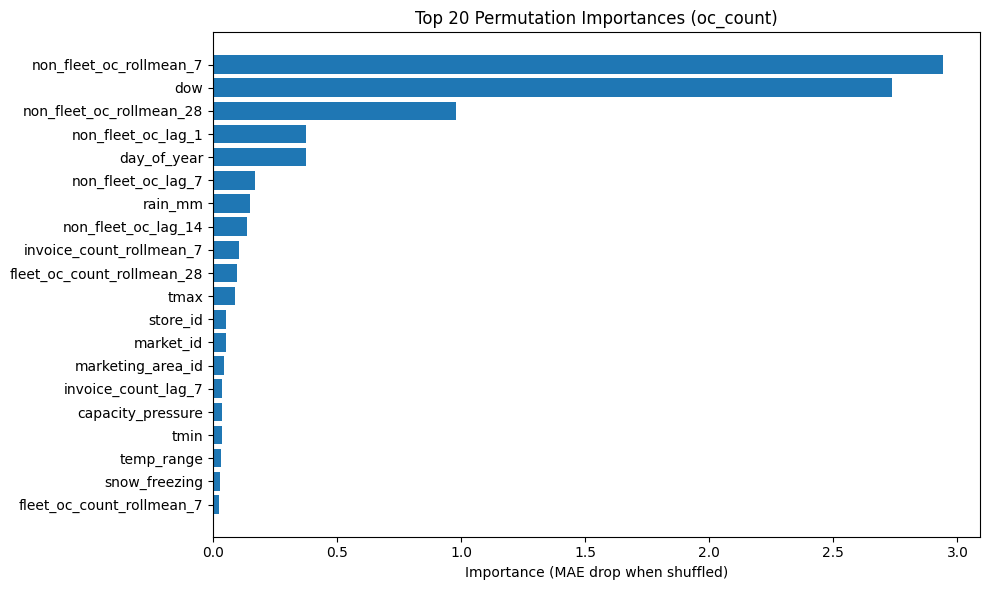

In [47]:
top20_oc = importance_df_oc.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top20_oc["feature"][::-1], top20_oc["importance_mean"][::-1])
plt.title("Top 20 Permutation Importances (oc_count)")
plt.xlabel("Importance (MAE drop when shuffled)")
plt.tight_layout()
plt.show()

In [48]:
importance_df_oc["is_weather"] = importance_df_oc["feature"].apply(is_weather_feature)

weather_summary_oc = (
    importance_df_oc.groupby("is_weather", as_index=False)["importance_mean"]
    .sum()
    .sort_values("importance_mean", ascending=False)
)

weather_summary_oc

,is_weather,importance_mean
0,False,8.285805
1,True,0.476984


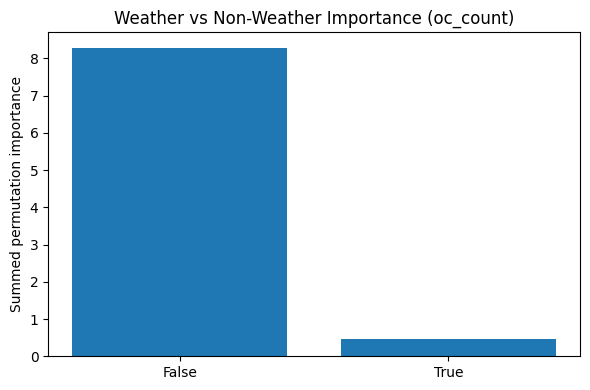

In [49]:
plt.figure(figsize=(6, 4))
plt.bar(weather_summary_oc["is_weather"].astype(str), weather_summary_oc["importance_mean"])
plt.title("Weather vs Non-Weather Importance (oc_count)")
plt.ylabel("Summed permutation importance")
plt.tight_layout()
plt.show()

In [50]:
comparison_ = pd.DataFrame({
    "target": ["invoice_count", "oc_count"],
    "full_mae": [full_mae, full_mae_oc],
    "no_weather_mae": [no_weather_mae, no_weather_mae_oc],
})

comparison_["mae_delta_no_weather_minus_full"] = (
    comparison_["no_weather_mae"] - comparison_["full_mae"]
)

comparison_

,target,full_mae,no_weather_mae,mae_delta_no_weather_minus_full
0,invoice_count,6.425706,6.530274,0.104568
1,oc_count,5.700331,5.824447,0.124117


## Key Findings

The updated HGB forecasting model is driven primarily by **calendar structure and recent demand history**. The strongest predictive features include day-of-week effects and short-term demand memory variables such as rolling demand averages and lagged demand signals.

For `invoice_count`, the most influential features include:

- `invoice_count_rollmean_7`
- `dow`
- `invoice_count_rollmean_28`
- `invoice_count_lag_1`
- `day_of_year`

For `oc_count`, the strongest features are dominated by non-fleet demand memory signals, including:

- `non_fleet_oc_rollmean_7`
- `dow`
- `non_fleet_oc_rollmean_28`
- `non_fleet_oc_lag_1`
- `day_of_year`

Weather-related variables such as `rain_mm`, `tmax`, `tmin`, `temp_range`, and snow-related features also appear in the top 20 predictors, but they are clearly secondary to demand-memory and calendar signals.

To test whether weather features materially improve forecasting, the full model was compared against a version trained without weather-related variables.

Removing weather increased validation MAE from:

- **6.426 to 6.530** for `invoice_count`
- **5.700 to 5.824** for `oc_count`

This confirms that weather features provide **measurable predictive value** for both targets, even though they are not the dominant drivers of demand.

## Interpretation

The forecasting model’s strongest predictive power comes from stable demand structure: recurring store behavior, day-of-week effects, day-of-year seasonality, and recent demand history. This is expected in retail demand forecasting, where much of day-to-day traffic is explained by repeating operational patterns.

However, weather features still improve forecast accuracy. The no-weather comparison shows that removing weather consistently degrades model performance for both invoice traffic and oil-change demand. This indicates that weather acts as a **secondary but meaningful adjustment signal** around the normal baseline demand pattern.

The feature importance results also support this interpretation. Weather variables are visible among the important predictors, especially rainfall and temperature-related features, but they rank below the core demand-memory signals. This means the system should be described as a **baseline demand forecasting model with weather adjustment**, rather than a weather-only prediction model.